## Step 1: Data Preparation & Reproducibility

In [1]:
# ============================================================
# 1. DATA PREPARATION & REPRODUCIBILITY (COLAB VERSION)
# ============================================================

# -----------------------------
# 1.1 Upload ZIP files manually
# -----------------------------
from google.colab import files

print("Upload the following files:")
print("- seg_train.zip")
print("- seg_test.zip")
print("- (optional) seg_pred.zip")

uploaded = files.upload()   # This opens file picker

Upload the following files:
- seg_train.zip
- seg_test.zip
- (optional) seg_pred.zip


Saving seg_pred.zip to seg_pred (1).zip


In [2]:
# Uploading Training Dataset
uploaded = files.upload()

Saving seg_train.zip to seg_train (1).zip


In [3]:
# Uploading Test Dataset
uploaded = files.upload()

Saving seg_test.zip to seg_test (1).zip


In [4]:
# -----------------------------
# 1.2 Unzipping uploaded files
# -----------------------------
import os
import zipfile

def unzip_file(zip_name):
    if zip_name in os.listdir():
        folder_name = zip_name.replace(".zip", "")
        if not os.path.exists(folder_name):
            print(f"Extracting {zip_name}...")
            with zipfile.ZipFile(zip_name, 'r') as zip_ref:
                zip_ref.extractall()
        else:
            print(f"{folder_name} already exists.")
    else:
        print(f"{zip_name} not found.")

unzip_file("seg_train.zip")
unzip_file("seg_test.zip")
unzip_file("seg_pred.zip")  # optional

seg_train already exists.
seg_test already exists.
seg_pred already exists.


In [5]:
# -----------------------------
# 1.3 Imports
# -----------------------------
import random
import numpy as np
from collections import Counter

import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split

# -----------------------------
# 1.4 Reproducibility
# -----------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# -----------------------------
# 1.5 Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -----------------------------
# 1.6 Paths
# -----------------------------
train_dir = "seg_train"
test_dir  = "seg_test"

# -----------------------------
# 1.7 Load dataset structure
# -----------------------------
temp_dataset = datasets.ImageFolder(train_dir)
class_names = temp_dataset.classes
class_to_idx = temp_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

print("Classes:", class_names)

# -----------------------------
# 1.8 Transforms (224x224)
# -----------------------------
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform_baseline = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

train_transform_aug = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# -----------------------------
# 1.9 Train / Validation Split
# -----------------------------
full_train_dataset = datasets.ImageFolder(train_dir)
targets = full_train_dataset.targets
indices = np.arange(len(targets))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.10,
    stratify=targets,
    random_state=42
)

# Datasets
train_dataset_baseline = datasets.ImageFolder(train_dir, transform=train_transform_baseline)
train_dataset_aug      = datasets.ImageFolder(train_dir, transform=train_transform_aug)
val_dataset            = datasets.ImageFolder(train_dir, transform=eval_transform)
test_dataset           = datasets.ImageFolder(test_dir,  transform=eval_transform)

# Subsets
train_subset_baseline = Subset(train_dataset_baseline, train_idx)
train_subset_aug      = Subset(train_dataset_aug, train_idx)
val_subset            = Subset(val_dataset, val_idx)

# -----------------------------
# 1.10 Class Counts
# -----------------------------
def count_classes(dataset, indices=None):
    if indices is not None:
        labels = [dataset.targets[i] for i in indices]
    else:
        labels = dataset.targets
    return Counter(labels)

print("\nTrain counts:", count_classes(full_train_dataset, train_idx))
print("Val counts:", count_classes(full_train_dataset, val_idx))
print("Test counts:", count_classes(test_dataset))

# -----------------------------
# 1.11 Dataloaders
# -----------------------------
BATCH_SIZE = 64

train_loader_baseline = DataLoader(train_subset_baseline, batch_size=BATCH_SIZE, shuffle=True)
train_loader_aug      = DataLoader(train_subset_aug, batch_size=BATCH_SIZE, shuffle=True)
val_loader            = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader           = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# -----------------------------
# 1.12 Sanity Check
# -----------------------------
images, labels = next(iter(train_loader_aug))

print("\nSanity Check:")
print("Images shape:", images.shape)  # [B, 3, 224, 224]
print("Labels shape:", labels.shape)

Device: cuda
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Train counts: Counter({3: 2261, 2: 2163, 5: 2144, 4: 2046, 1: 2044, 0: 1972})
Val counts: Counter({3: 251, 2: 241, 5: 238, 4: 228, 1: 227, 0: 219})
Test counts: Counter({2: 553, 3: 525, 4: 510, 5: 501, 1: 474, 0: 437})

Sanity Check:
Images shape: torch.Size([64, 3, 224, 224])
Labels shape: torch.Size([64])


## Step 2: Custom Components (Implement & Test)

In [6]:
# ============================================================
# 2. CUSTOM COMPONENTS (IMPLEMENT & TEST)
# ============================================================

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Function

# ============================================================
# 2.1 CUSTOM ACTIVATIONS
# ============================================================

# ------------------------------------------------------------
# Swish
# y = x * sigmoid(beta * x)
# if learnable: beta = exp(log_beta) to keep beta > 0
# ------------------------------------------------------------
class Swish(nn.Module):
    def __init__(self, learnable_beta=False, init_beta=1.0):
        super().__init__()
        self.learnable_beta = learnable_beta

        if learnable_beta:
            init_log_beta = math.log(init_beta)
            self.log_beta = nn.Parameter(torch.tensor(init_log_beta, dtype=torch.float32))
        else:
            self.register_buffer("beta_const", torch.tensor(init_beta, dtype=torch.float32))

    def forward(self, x):
        if self.learnable_beta:
            beta = torch.exp(self.log_beta).to(dtype=x.dtype, device=x.device)
        else:
            beta = self.beta_const.to(dtype=x.dtype, device=x.device)

        return x * torch.sigmoid(beta * x)


# ------------------------------------------------------------
# HardSwish via torch.autograd.Function
# HardSwish(x) = x * relu6(x + 3) / 6
# piecewise:
#   0                  if x <= -3
#   x                  if x >= 3
#   x(x+3)/6           otherwise
#
# derivative:
#   0                  if x <= -3
#   1                  if x >= 3
#   (2x + 3)/6         otherwise
# ------------------------------------------------------------
class HardSwishFn(Function):
    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x)

        out = torch.empty_like(x)
        out[x <= -3] = 0.0
        out[x >= 3] = x[x >= 3]

        mid = (x > -3) & (x < 3)
        out[mid] = x[mid] * (x[mid] + 3.0) / 6.0
        return out

    @staticmethod
    def backward(ctx, grad_output):
        (x,) = ctx.saved_tensors

        grad_input = torch.zeros_like(x)
        grad_input[x >= 3] = 1.0

        mid = (x > -3) & (x < 3)
        grad_input[mid] = (2.0 * x[mid] + 3.0) / 6.0

        return grad_output * grad_input


class HardSwish(nn.Module):
    def forward(self, x):
        return HardSwishFn.apply(x)


# ============================================================
# 2.2 UNIT TESTS FOR ACTIVATIONS
# Use double precision and avoid exactly ±3 for gradcheck
# ============================================================

def run_activation_gradchecks():
    print("Running gradcheck for custom activations...")

    # Swish gradcheck
    swish = Swish(learnable_beta=True, init_beta=1.0).double()
    x1 = torch.randn(4, 5, dtype=torch.double, requires_grad=True) * 0.5
    swish_ok = torch.autograd.gradcheck(swish, (x1,), eps=1e-6, atol=1e-4)
    print("Swish gradcheck passed:", swish_ok)

    # HardSwish gradcheck
    # keep values away from exactly -3 and 3
    x2 = (torch.rand(4, 5, dtype=torch.double) * 5.0 - 2.5).requires_grad_(True)
    hswish_ok = torch.autograd.gradcheck(HardSwishFn.apply, (x2,), eps=1e-6, atol=1e-4)
    print("HardSwish gradcheck passed:", hswish_ok)

run_activation_gradchecks()


# ============================================================
# 2.3 CUSTOM LAYERS
# ============================================================

# ------------------------------------------------------------
# ResidualConv(in_ch)
# channel-preserving:
# x + alpha * Dropout(BN(Act(Conv(x))))
# alpha = exp(log_alpha)
# ------------------------------------------------------------
class ResidualConv(nn.Module):
    def __init__(self, in_ch, activation=None, dropout=0.10, init_alpha=1.0):
        super().__init__()

        self.conv = nn.Conv2d(
            in_channels=in_ch,
            out_channels=in_ch,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn = nn.BatchNorm2d(in_ch)
        self.act = activation if activation is not None else Swish(learnable_beta=False)
        self.dropout = nn.Dropout2d(p=dropout)

        init_log_alpha = math.log(init_alpha)
        self.log_alpha = nn.Parameter(torch.tensor(init_log_alpha, dtype=torch.float32))

        self._init_weights()

    def _init_weights(self):
        nn.init.kaiming_normal_(self.conv.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x):
        alpha = torch.exp(self.log_alpha).to(dtype=x.dtype, device=x.device)
        residual = self.conv(x)
        residual = self.bn(residual)
        residual = self.act(residual)
        residual = self.dropout(residual)
        return x + alpha * residual


# ------------------------------------------------------------
# SqueezeExcite2d(C, r=16)
# Channel attention gate
# ------------------------------------------------------------
class SqueezeExcite2d(nn.Module):
    def __init__(self, channels, r=16):
        super().__init__()
        hidden = max(channels // r, 1)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Conv2d(channels, hidden, kernel_size=1)
        self.fc2 = nn.Conv2d(hidden, channels, kernel_size=1)
        self.act = nn.ReLU(inplace=True)
        self.gate = nn.Sigmoid()

    def forward(self, x):
        s = self.pool(x)
        s = self.fc1(s)
        s = self.act(s)
        s = self.fc2(s)
        s = self.gate(s)
        return x * s


# ============================================================
# 2.4 CUSTOM LOSSES
# ============================================================

# ------------------------------------------------------------
# LabelSmoothingCrossEntropy
# eps in [0, 0.2]
# logit-stable implementation
# ------------------------------------------------------------
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, eps=0.1):
        super().__init__()
        if not (0.0 <= eps <= 0.2):
            raise ValueError("eps must be in [0, 0.2]")
        self.eps = eps

    def forward(self, logits, target):
        num_classes = logits.size(1)
        log_probs = F.log_softmax(logits, dim=1)

        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.eps / (num_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.eps)

        loss = (-true_dist * log_probs).sum(dim=1).mean()
        return loss


# ------------------------------------------------------------
# FocalLossMulticlass
# stable one-vs-rest formulation on logits
# alpha can be:
#   None
#   scalar
#   list/tuple/tensor of length C
# ------------------------------------------------------------
class FocalLossMulticlass(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, target):
        num_classes = logits.size(1)

        target_one_hot = F.one_hot(target, num_classes=num_classes).to(dtype=logits.dtype)

        # BCE with logits for one-vs-rest multiclass formulation
        bce = F.binary_cross_entropy_with_logits(
            logits, target_one_hot, reduction='none'
        )

        probs = torch.sigmoid(logits)
        pt = target_one_hot * probs + (1.0 - target_one_hot) * (1.0 - probs)
        focal_factor = (1.0 - pt).pow(self.gamma)

        loss = focal_factor * bce

        if self.alpha is not None:
            if isinstance(self.alpha, (float, int)):
                alpha_t = torch.full((num_classes,), float(self.alpha),
                                     device=logits.device, dtype=logits.dtype)
            else:
                alpha_t = torch.tensor(self.alpha, device=logits.device, dtype=logits.dtype)

            loss = loss * alpha_t.view(1, -1)

        loss = loss.sum(dim=1)  # sum over classes

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss


# ============================================================
# 2.5 CUSTOM METRICS
# ============================================================

# ------------------------------------------------------------
# MacroF1Meter(C=6)
# ------------------------------------------------------------
class MacroF1Meter:
    def __init__(self, num_classes=6):
        self.num_classes = num_classes
        self.reset()

    def reset(self):
        self.cm = torch.zeros(self.num_classes, self.num_classes, dtype=torch.long)

    @torch.no_grad()
    def update(self, logits, target):
        preds = torch.argmax(logits, dim=1).view(-1).cpu()
        target = target.view(-1).cpu()

        for t, p in zip(target, preds):
            self.cm[t.long(), p.long()] += 1

    def compute(self):
        cm = self.cm.float()

        tp = torch.diag(cm)
        fp = cm.sum(dim=0) - tp
        fn = cm.sum(dim=1) - tp

        precision = tp / (tp + fp + 1e-12)
        recall = tp / (tp + fn + 1e-12)
        f1 = 2 * precision * recall / (precision + recall + 1e-12)

        return f1.mean().item()


# ------------------------------------------------------------
# TopKAccuracy(k=1,5)
# ------------------------------------------------------------
class TopKAccuracy:
    def __init__(self, ks=(1, 5)):
        self.ks = ks
        self.reset()

    def reset(self):
        self.correct = {k: 0 for k in self.ks}
        self.total = 0

    @torch.no_grad()
    def update(self, logits, target):
        max_k = max(self.ks)
        _, pred = logits.topk(max_k, dim=1, largest=True, sorted=True)
        pred = pred.t()
        correct = pred.eq(target.view(1, -1).expand_as(pred))

        batch_size = target.size(0)
        self.total += batch_size

        for k in self.ks:
            correct_k = correct[:k].any(dim=0).sum().item()
            self.correct[k] += correct_k

    def compute(self):
        return {f"top_{k}_acc": self.correct[k] / max(self.total, 1) for k in self.ks}


# ============================================================
# 2.6 QUICK SANITY TESTS
# ============================================================

def run_component_sanity_tests():
    print("\nRunning component sanity tests...")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Dummy input
    x = torch.randn(8, 32, 56, 56).to(device)

    # Activations
    swish = Swish(learnable_beta=True).to(device)
    hswish = HardSwish().to(device)

    y1 = swish(x)
    y2 = hswish(x)
    print("Swish output shape:", y1.shape)
    print("HardSwish output shape:", y2.shape)

    # Layers
    res_block = ResidualConv(32, activation=Swish(learnable_beta=False), dropout=0.1).to(device)
    se_block = SqueezeExcite2d(32, r=16).to(device)

    y3 = res_block(x)
    y4 = se_block(x)
    print("ResidualConv output shape:", y3.shape)
    print("SqueezeExcite2d output shape:", y4.shape)

    # Losses
    logits = torch.randn(8, 6).to(device)
    targets = torch.randint(0, 6, (8,)).to(device)

    ls_loss_fn = LabelSmoothingCrossEntropy(eps=0.1)
    focal_loss_fn = FocalLossMulticlass(alpha=None, gamma=2.0)

    ls_loss = ls_loss_fn(logits, targets)
    focal_loss = focal_loss_fn(logits, targets)

    print("LabelSmoothingCrossEntropy:", float(ls_loss))
    print("FocalLossMulticlass:", float(focal_loss))

    # Metrics
    macro_f1 = MacroF1Meter(num_classes=6)
    topk = TopKAccuracy(ks=(1, 5))

    macro_f1.update(logits.detach().cpu(), targets.detach().cpu())
    topk.update(logits.detach().cpu(), targets.detach().cpu())

    print("Macro F1:", macro_f1.compute())
    print("Top-k Accuracy:", topk.compute())

run_component_sanity_tests()

Running gradcheck for custom activations...
Swish gradcheck passed: True
HardSwish gradcheck passed: True

Running component sanity tests...
Swish output shape: torch.Size([8, 32, 56, 56])
HardSwish output shape: torch.Size([8, 32, 56, 56])
ResidualConv output shape: torch.Size([8, 32, 56, 56])
SqueezeExcite2d output shape: torch.Size([8, 32, 56, 56])
LabelSmoothingCrossEntropy: 1.9868937730789185
FocalLossMulticlass: 1.9074034690856934
Macro F1: 0.23333333432674408
Top-k Accuracy: {'top_1_acc': 0.25, 'top_5_acc': 0.875}


## Step 3 — Part 1: Model Definitions

In [7]:
# ============================================================
# 3. MODELS (Baseline, Augmented, Transfer, Custom)
# ============================================================

import torch
import torch.nn as nn
import torchvision.models as models

# ============================================================
# 3.1 HELPER BLOCK: Conv-BN-ReLU
# ============================================================

class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=1, act=None):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = act if act is not None else nn.ReLU(inplace=True)

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))


# ============================================================
# 3.2 BASELINE CNN (NO AUGMENTATION)
# Conv-BN-ReLU stacks → GlobalAvgPool → Linear(6)
# ============================================================

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()

        self.features = nn.Sequential(
            ConvBNAct(3, 32),
            ConvBNAct(32, 64, stride=2),
            ConvBNAct(64, 128, stride=2),
            ConvBNAct(128, 256, stride=2),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


# ============================================================
# 3.3 AUGMENTED CNN
# SAME architecture as baseline (only data changes)
# ============================================================

# Just reuse BaselineCNN
AugmentedCNN = BaselineCNN


# ============================================================
# 3.4 TRANSFER LEARNING (ResNet-18)
# Compare frozen vs full fine-tuning
# ============================================================

def get_resnet18_model(num_classes=6, pretrained=True, freeze_backbone=True):
    weights = models.ResNet18_Weights.DEFAULT if pretrained else None
    model = models.resnet18(weights=weights)

    # Replace final layer
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    if freeze_backbone:
        for name, param in model.named_parameters():
            if "fc" not in name:
                param.requires_grad = False

    return model


# ============================================================
# 3.5 CUSTOM NET (Your custom components)
# Replace ReLU → Swish / HardSwish
# Add ResidualConv + SqueezeExcite
# ============================================================

class CustomNet(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()

        # Using your custom activations
        act = Swish(learnable_beta=False)

        self.stem = ConvBNAct(3, 32, act=act)

        self.block1 = nn.Sequential(
            ConvBNAct(32, 64, stride=2, act=act),
            ResidualConv(64, activation=act),
            SqueezeExcite2d(64)
        )

        self.block2 = nn.Sequential(
            ConvBNAct(64, 128, stride=2, act=act),
            ResidualConv(128, activation=act),
            SqueezeExcite2d(128)
        )

        self.block3 = nn.Sequential(
            ConvBNAct(128, 256, stride=2, act=act),
            ResidualConv(256, activation=act),
            SqueezeExcite2d(256)
        )

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


# ============================================================
# 3.6 SANITY CHECK ALL MODELS
# ============================================================

def test_models():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    x = torch.randn(8, 3, 224, 224).to(device)

    print("\nTesting Baseline CNN...")
    model1 = BaselineCNN().to(device)
    print(model1(x).shape)

    print("\nTesting Augmented CNN...")
    model2 = AugmentedCNN().to(device)
    print(model2(x).shape)

    print("\nTesting ResNet18 (Frozen)...")
    model3 = get_resnet18_model(freeze_backbone=True).to(device)
    print(model3(x).shape)

    print("\nTesting ResNet18 (Fine-tune)...")
    model4 = get_resnet18_model(freeze_backbone=False).to(device)
    print(model4(x).shape)

    print("\nTesting CustomNet...")
    model5 = CustomNet().to(device)
    print(model5(x).shape)

test_models()


Testing Baseline CNN...
torch.Size([8, 6])

Testing Augmented CNN...
torch.Size([8, 6])

Testing ResNet18 (Frozen)...
torch.Size([8, 6])

Testing ResNet18 (Fine-tune)...
torch.Size([8, 6])

Testing CustomNet...
torch.Size([8, 6])


In [8]:
# ============================================================
# 3. MODELS - PART 2: EXPERIMENT SETUP
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 6

# ------------------------------------------------------------
# 3.1 Instantiate models
# ------------------------------------------------------------
baseline_model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
augmented_model = AugmentedCNN(num_classes=NUM_CLASSES).to(device)

transfer_frozen_model = get_resnet18_model(
    num_classes=NUM_CLASSES,
    pretrained=True,
    freeze_backbone=True
).to(device)

transfer_finetune_model = get_resnet18_model(
    num_classes=NUM_CLASSES,
    pretrained=True,
    freeze_backbone=False
).to(device)

custom_model = CustomNet(num_classes=NUM_CLASSES).to(device)

# ------------------------------------------------------------
# 3.2 Loss functions
# ------------------------------------------------------------
ce_loss = nn.CrossEntropyLoss()
label_smooth_loss = LabelSmoothingCrossEntropy(eps=0.1)
focal_loss = FocalLossMulticlass(alpha=None, gamma=2.0)

# ------------------------------------------------------------
# 3.3 Optimizers
# ------------------------------------------------------------
baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=1e-3)

augmented_optimizer = optim.Adam(augmented_model.parameters(), lr=1e-3)

transfer_frozen_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, transfer_frozen_model.parameters()),
    lr=1e-3
)

transfer_finetune_optimizer = optim.Adam(
    transfer_finetune_model.parameters(),
    lr=1e-4
)

custom_optimizer = optim.Adam(custom_model.parameters(), lr=1e-3)

# ------------------------------------------------------------
# 3.4 Optional schedulers
# ------------------------------------------------------------
baseline_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    baseline_optimizer, mode='max', factor=0.5, patience=2
)

augmented_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    augmented_optimizer, mode='max', factor=0.5, patience=2
)

transfer_frozen_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    transfer_frozen_optimizer, mode='max', factor=0.5, patience=2
)

transfer_finetune_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    transfer_finetune_optimizer, mode='max', factor=0.5, patience=2
)

custom_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    custom_optimizer, mode='max', factor=0.5, patience=2
)

# ------------------------------------------------------------
# 3.5 Organize experiments
# ------------------------------------------------------------
experiments = {
    "baseline_cnn": {
        "model": baseline_model,
        "train_loader": train_loader_baseline,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "criterion": ce_loss,
        "optimizer": baseline_optimizer,
        "scheduler": baseline_scheduler
    },

    "augmented_cnn": {
        "model": augmented_model,
        "train_loader": train_loader_aug,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "criterion": ce_loss,
        "optimizer": augmented_optimizer,
        "scheduler": augmented_scheduler
    },

    "transfer_resnet18_frozen": {
        "model": transfer_frozen_model,
        "train_loader": train_loader_aug,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "criterion": ce_loss,
        "optimizer": transfer_frozen_optimizer,
        "scheduler": transfer_frozen_scheduler
    },

    "transfer_resnet18_finetune": {
        "model": transfer_finetune_model,
        "train_loader": train_loader_aug,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "criterion": ce_loss,
        "optimizer": transfer_finetune_optimizer,
        "scheduler": transfer_finetune_scheduler
    },

    "custom_net": {
        "model": custom_model,
        "train_loader": train_loader_aug,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "criterion": label_smooth_loss,
        "optimizer": custom_optimizer,
        "scheduler": custom_scheduler
    }
}

# ------------------------------------------------------------
# 3.6 Print summary
# ------------------------------------------------------------
print("Experiment Setup Complete\n")

for name, cfg in experiments.items():
    model = cfg["model"]
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"{name}")
    print(f"  Model Type        : {model.__class__.__name__}")
    print(f"  Total Params      : {total_params:,}")
    print(f"  Trainable Params  : {trainable_params:,}")
    print(f"  Loss Function     : {cfg['criterion'].__class__.__name__}")
    print(f"  Optimizer         : {cfg['optimizer'].__class__.__name__}")
    print("-" * 60)

Experiment Setup Complete

baseline_cnn
  Model Type        : BaselineCNN
  Total Params      : 390,438
  Trainable Params  : 390,438
  Loss Function     : CrossEntropyLoss
  Optimizer         : Adam
------------------------------------------------------------
augmented_cnn
  Model Type        : BaselineCNN
  Total Params      : 390,438
  Trainable Params  : 390,438
  Loss Function     : CrossEntropyLoss
  Optimizer         : Adam
------------------------------------------------------------
transfer_resnet18_frozen
  Model Type        : ResNet
  Total Params      : 11,179,590
  Trainable Params  : 3,078
  Loss Function     : CrossEntropyLoss
  Optimizer         : Adam
------------------------------------------------------------
transfer_resnet18_finetune
  Model Type        : ResNet
  Total Params      : 11,179,590
  Trainable Params  : 11,179,590
  Loss Function     : CrossEntropyLoss
  Optimizer         : Adam
------------------------------------------------------------
custom_net
  

## Step 4 — Part 1: Training + Evaluation Pipeline

In [9]:
# ============================================================
# 4. TRAINING + EVALUATION PIPELINE
# ============================================================

import torch
from tqdm import tqdm

# ============================================================
# 4.1 TRAIN FUNCTION
# ============================================================

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0
    macro_f1 = MacroF1Meter(num_classes=6)
    topk = TopKAccuracy(ks=(1, 5))

    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        macro_f1.update(outputs.detach().cpu(), labels.detach().cpu())
        topk.update(outputs.detach().cpu(), labels.detach().cpu())

    avg_loss = total_loss / len(loader.dataset)

    return {
        "loss": avg_loss,
        "macro_f1": macro_f1.compute(),
        **topk.compute()
    }


# ============================================================
# 4.2 VALIDATION FUNCTION
# ============================================================

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    macro_f1 = MacroF1Meter(num_classes=6)
    topk = TopKAccuracy(ks=(1, 5))

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)

        macro_f1.update(outputs.cpu(), labels.cpu())
        topk.update(outputs.cpu(), labels.cpu())

    avg_loss = total_loss / len(loader.dataset)

    return {
        "loss": avg_loss,
        "macro_f1": macro_f1.compute(),
        **topk.compute()
    }


# ============================================================
# 4.3 FULL TRAINING LOOP
# ============================================================

def train_model(cfg, epochs=5):
    model = cfg["model"]
    train_loader = cfg["train_loader"]
    val_loader = cfg["val_loader"]
    criterion = cfg["criterion"]
    optimizer = cfg["optimizer"]
    scheduler = cfg["scheduler"]

    best_f1 = 0
    history = []

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = evaluate(model, val_loader, criterion, device)

        scheduler.step(val_metrics["macro_f1"])

        print(f"Train Loss: {train_metrics['loss']:.4f} | F1: {train_metrics['macro_f1']:.4f}")
        print(f"Val   Loss: {val_metrics['loss']:.4f} | F1: {val_metrics['macro_f1']:.4f}")

        history.append({
            "epoch": epoch + 1,
            "train": train_metrics,
            "val": val_metrics
        })

        # Save best model
        if val_metrics["macro_f1"] > best_f1:
            best_f1 = val_metrics["macro_f1"]
            best_state = model.state_dict()

    model.load_state_dict(best_state)

    return model, history

### Step 4 — Part 2: Train All Models

In [10]:
# Train Baseline
baseline_trained, baseline_history = train_model(experiments["baseline_cnn"], epochs=5)


Epoch 1/5


Train Loss: 1.0146 | F1: 0.6027
Val   Loss: 1.0021 | F1: 0.5832

Epoch 2/5


Train Loss: 0.7612 | F1: 0.7197
Val   Loss: 0.7250 | F1: 0.6840

Epoch 3/5


Train Loss: 0.6845 | F1: 0.7517
Val   Loss: 0.7909 | F1: 0.6977

Epoch 4/5


Train Loss: 0.6306 | F1: 0.7720
Val   Loss: 0.6165 | F1: 0.7850

Epoch 5/5


Train Loss: 0.5893 | F1: 0.7873
Val   Loss: 0.5758 | F1: 0.7874


In [11]:
# Train Augmented
aug_trained, aug_history = train_model(experiments["augmented_cnn"], epochs=5)


Epoch 1/5


Train Loss: 1.2273 | F1: 0.4921
Val   Loss: 0.9461 | F1: 0.6261

Epoch 2/5


Train Loss: 1.0201 | F1: 0.6066
Val   Loss: 0.8302 | F1: 0.6498

Epoch 3/5


Train Loss: 0.9303 | F1: 0.6428
Val   Loss: 0.8645 | F1: 0.6344

Epoch 4/5


Train Loss: 0.8822 | F1: 0.6619
Val   Loss: 0.7314 | F1: 0.7429

Epoch 5/5


Train Loss: 0.8493 | F1: 0.6799
Val   Loss: 0.7034 | F1: 0.7655


In [12]:
# Train Transfer (Frozen)
tf_frozen_trained, tf_frozen_history = train_model(experiments["transfer_resnet18_frozen"], epochs=5)


Epoch 1/5


Train Loss: 0.7498 | F1: 0.7394
Val   Loss: 0.3466 | F1: 0.8873

Epoch 2/5


Train Loss: 0.4728 | F1: 0.8338
Val   Loss: 0.3058 | F1: 0.8968

Epoch 3/5


Train Loss: 0.4404 | F1: 0.8397
Val   Loss: 0.2794 | F1: 0.9059

Epoch 4/5


Train Loss: 0.4302 | F1: 0.8423
Val   Loss: 0.2900 | F1: 0.9009

Epoch 5/5


Train Loss: 0.4191 | F1: 0.8486
Val   Loss: 0.2742 | F1: 0.9062


In [13]:
# Train Transfer (Fine-tune)
tf_ft_trained, tf_ft_history = train_model(experiments["transfer_resnet18_finetune"], epochs=5)


Epoch 1/5


Train Loss: 0.4428 | F1: 0.8410
Val   Loss: 0.2332 | F1: 0.9126

Epoch 2/5


Train Loss: 0.3146 | F1: 0.8878
Val   Loss: 0.1946 | F1: 0.9298

Epoch 3/5


Train Loss: 0.3009 | F1: 0.8887
Val   Loss: 0.1810 | F1: 0.9365

Epoch 4/5


Train Loss: 0.2719 | F1: 0.8971
Val   Loss: 0.1728 | F1: 0.9346

Epoch 5/5


Train Loss: 0.2561 | F1: 0.9053
Val   Loss: 0.2262 | F1: 0.9223


In [14]:
# Train CustomNet
custom_trained, custom_history = train_model(experiments["custom_net"], epochs=5)


Epoch 1/5


Train Loss: 1.3425 | F1: 0.5123
Val   Loss: 1.1052 | F1: 0.6598

Epoch 2/5


Train Loss: 1.1640 | F1: 0.6320
Val   Loss: 0.9988 | F1: 0.7193

Epoch 3/5


Train Loss: 1.0900 | F1: 0.6730
Val   Loss: 0.9692 | F1: 0.7570

Epoch 4/5


Train Loss: 1.0502 | F1: 0.7058
Val   Loss: 0.8989 | F1: 0.7892

Epoch 5/5


Train Loss: 1.0063 | F1: 0.7272
Val   Loss: 0.8916 | F1: 0.8036


### Step 4 — Part 3: Final Test Evaluation

In [15]:
def test_model(model, cfg):
    return evaluate(model, cfg["test_loader"], cfg["criterion"], device)


results = {
    "baseline": test_model(baseline_trained, experiments["baseline_cnn"]),
    "augmented": test_model(aug_trained, experiments["augmented_cnn"]),
    "transfer_frozen": test_model(tf_frozen_trained, experiments["transfer_resnet18_frozen"]),
    "transfer_finetune": test_model(tf_ft_trained, experiments["transfer_resnet18_finetune"]),
    "custom": test_model(custom_trained, experiments["custom_net"]),
}

print("\nFinal Test Results:")
for k, v in results.items():
    print(k, v)


Final Test Results:
baseline {'loss': 0.5722056325276693, 'macro_f1': 0.7904607653617859, 'top_1_acc': 0.7963333333333333, 'top_5_acc': 0.998}
augmented {'loss': 0.6914259856541951, 'macro_f1': 0.7526151537895203, 'top_1_acc': 0.7486666666666667, 'top_5_acc': 0.9963333333333333}
transfer_frozen {'loss': 0.2779902785817782, 'macro_f1': 0.906332790851593, 'top_1_acc': 0.9053333333333333, 'top_5_acc': 0.998}
transfer_finetune {'loss': 0.22416369299093883, 'macro_f1': 0.9188905358314514, 'top_1_acc': 0.9176666666666666, 'top_5_acc': 1.0}
custom {'loss': 0.8853823016484579, 'macro_f1': 0.8096868395805359, 'top_1_acc': 0.8076666666666666, 'top_5_acc': 0.9986666666666667}


### Explanation:
The fine-tuned ResNet-18 model performed the best among all models, achieving the highest macro F1 score (0.919) and top-1 accuracy (0.918). This shows that transfer learning with full fine-tuning is highly effective, as it leverages pretrained features from ImageNet and adapts them to the target dataset. The frozen version also performed well but slightly lower, indicating that updating all layers improves performance. The baseline and augmented CNN models showed lower performance, highlighting the importance of pretrained representations. The custom model improved over baseline but did not outperform transfer learning. Therefore, the fine-tuned ResNet-18 is the best model for this task.

The augmented CNN performed slightly worse than the baseline model, which may be due to strong augmentation or limited training epochs leading to underfitting. Additionally, the custom network demonstrated improved performance over the baseline but could not surpass transfer learning, indicating that pretrained models are more powerful for this dataset.



## Step 5 — Minimal Efficient Code

In [16]:
# ============================================================
# 5. ABLATION STUDIES
# ============================================================

def run_ablation(model_fn, cfg_base, epochs=2):
    model = model_fn().to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    cfg = {
        "model": model,
        "train_loader": cfg_base["train_loader"],
        "val_loader": cfg_base["val_loader"],
        "test_loader": cfg_base["test_loader"],
        "criterion": cfg_base["criterion"],
        "optimizer": optimizer,
        "scheduler": torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=1
        )
    }

    trained_model, _ = train_model(cfg, epochs=epochs)
    result = evaluate(trained_model, cfg["test_loader"], cfg["criterion"], device)

    return result

#### 5.1 Activation Ablation

In [17]:
# ReLU version
class CustomNet_ReLU(CustomNet):
    def __init__(self):
        super().__init__()
        self.stem.act = nn.ReLU()

# HardSwish version
class CustomNet_HardSwish(CustomNet):
    def __init__(self):
        super().__init__()
        self.stem.act = HardSwish()

print("Activation Ablation:")

relu_res = run_ablation(lambda: CustomNet_ReLU(), experiments["custom_net"])
swish_res = run_ablation(lambda: CustomNet(), experiments["custom_net"])
hswish_res = run_ablation(lambda: CustomNet_HardSwish(), experiments["custom_net"])

print("ReLU:", relu_res)
print("Swish:", swish_res)
print("HardSwish:", hswish_res)

Activation Ablation:

Epoch 1/2


Train Loss: 1.3170 | F1: 0.5313
Val   Loss: 1.1198 | F1: 0.6654

Epoch 2/2


Train Loss: 1.1476 | F1: 0.6428
Val   Loss: 1.0294 | F1: 0.7272

Epoch 1/2


Train Loss: 1.3418 | F1: 0.5085
Val   Loss: 1.0994 | F1: 0.6771

Epoch 2/2


Train Loss: 1.1640 | F1: 0.6303
Val   Loss: 1.0767 | F1: 0.6544

Epoch 1/2


Train Loss: 1.3369 | F1: 0.5152
Val   Loss: 1.1656 | F1: 0.6632

Epoch 2/2


Train Loss: 1.1536 | F1: 0.6428
Val   Loss: 0.9982 | F1: 0.7325
ReLU: {'loss': 1.0212225433985391, 'macro_f1': 0.7328489422798157, 'top_1_acc': 0.7333333333333333, 'top_5_acc': 0.994}
Swish: {'loss': 1.0679521641731262, 'macro_f1': 0.6728322505950928, 'top_1_acc': 0.689, 'top_5_acc': 0.9923333333333333}
HardSwish: {'loss': 1.009300477663676, 'macro_f1': 0.7159585356712341, 'top_1_acc': 0.716, 'top_5_acc': 0.9956666666666667}


#### Interpretation:

In this ablation, ReLU achieved the best performance, with the highest macro F1 score and top-1 accuracy among the three activation functions. HardSwish performed slightly lower but still remained competitive. Swish gave the lowest performance in this controlled setting. These results suggest that for this model and short training schedule, ReLU was the most effective activation, while the smoother custom activations did not provide an advantage.

#### 5.2 Loss Ablation

In [18]:
print("\nLoss Ablation:")

loss_configs = {
    "CE": nn.CrossEntropyLoss(),
    "LabelSmoothing": LabelSmoothingCrossEntropy(eps=0.1),
    "Focal": FocalLossMulticlass(gamma=2.0)
}

loss_results = {}

for name, loss_fn in loss_configs.items():
    cfg = experiments["custom_net"].copy()
    cfg["criterion"] = loss_fn

    res = run_ablation(lambda: CustomNet(), cfg)
    loss_results[name] = res

for k, v in loss_results.items():
    print(k, v)


Loss Ablation:

Epoch 1/2


Train Loss: 1.1638 | F1: 0.5193
Val   Loss: 0.8802 | F1: 0.6579

Epoch 2/2


Train Loss: 0.9245 | F1: 0.6368
Val   Loss: 0.7297 | F1: 0.7291

Epoch 1/2


Train Loss: 1.3544 | F1: 0.5028
Val   Loss: 1.1363 | F1: 0.6363

Epoch 2/2


Train Loss: 1.1685 | F1: 0.6342
Val   Loss: 1.0108 | F1: 0.7352

Epoch 1/2


Train Loss: 0.5356 | F1: 0.4881
Val   Loss: 0.4532 | F1: 0.5786

Epoch 2/2


Train Loss: 0.4449 | F1: 0.6049
Val   Loss: 0.3415 | F1: 0.7324
CE {'loss': 0.7616634672482808, 'macro_f1': 0.7072386741638184, 'top_1_acc': 0.7053333333333334, 'top_5_acc': 0.9963333333333333}
LabelSmoothing {'loss': 1.0233161125183106, 'macro_f1': 0.7196394801139832, 'top_1_acc': 0.716, 'top_5_acc': 0.9943333333333333}
Focal {'loss': 0.33758783610661824, 'macro_f1': 0.7333274483680725, 'top_1_acc': 0.7336666666666667, 'top_5_acc': 0.9973333333333333}


#### Interpretation
For the loss ablation, Focal Loss produced the best results, achieving the highest macro F1 and top-1 accuracy. Label Smoothing also improved performance compared to standard Cross-Entropy. This indicates that modifying the loss function helped the model generalize better, and in this experiment Focal Loss was the strongest option among the three tested losses.

#### 5.3 Layer Ablation

In [19]:
# Without Residual + SE
class CustomNet_NoExtras(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            ConvBNAct(3, 32),
            ConvBNAct(32, 64, stride=2),
            ConvBNAct(64, 128, stride=2),
            ConvBNAct(128, 256, stride=2),
            nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Linear(256, 6)

    def forward(self, x):
        x = self.net(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

print("\nLayer Ablation:")

with_layer = run_ablation(lambda: CustomNet(), experiments["custom_net"])
without_layer = run_ablation(lambda: CustomNet_NoExtras(), experiments["custom_net"])

print("With Residual + SE:", with_layer)
print("Without:", without_layer)


Layer Ablation:

Epoch 1/2


Train Loss: 1.3465 | F1: 0.5086
Val   Loss: 1.2149 | F1: 0.5849

Epoch 2/2


Train Loss: 1.1646 | F1: 0.6365
Val   Loss: 0.9883 | F1: 0.7461

Epoch 1/2


Train Loss: 1.3918 | F1: 0.4971
Val   Loss: 1.2263 | F1: 0.5955

Epoch 2/2


Train Loss: 1.2584 | F1: 0.5953
Val   Loss: 1.1276 | F1: 0.6282
With Residual + SE: {'loss': 1.0022925786972046, 'macro_f1': 0.7370281219482422, 'top_1_acc': 0.7363333333333333, 'top_5_acc': 0.9966666666666667}
Without: {'loss': 1.1475518054962157, 'macro_f1': 0.6181798577308655, 'top_1_acc': 0.6356666666666667, 'top_5_acc': 0.9953333333333333}


#### Interpretation
The model with ResidualConv and Squeeze-and-Excitation performed much better than the version without these components. It achieved a noticeably higher macro F1 score and top-1 accuracy. This shows that the added residual connection and channel attention mechanism improved feature learning and helped the model capture more useful information from the images.

#### Overall Ablation Summary
The ablation study showed that different design choices had measurable effects on performance. ReLU was the strongest activation in this setting, Focal Loss was the best-performing loss function, and adding ResidualConv with Squeeze-and-Excitation gave a clear improvement over the simpler model. These results confirm that architecture and loss design meaningfully influence model performance.

### Step 6 — Visualizations & Error Analysis

#### 6.1 Training Curves

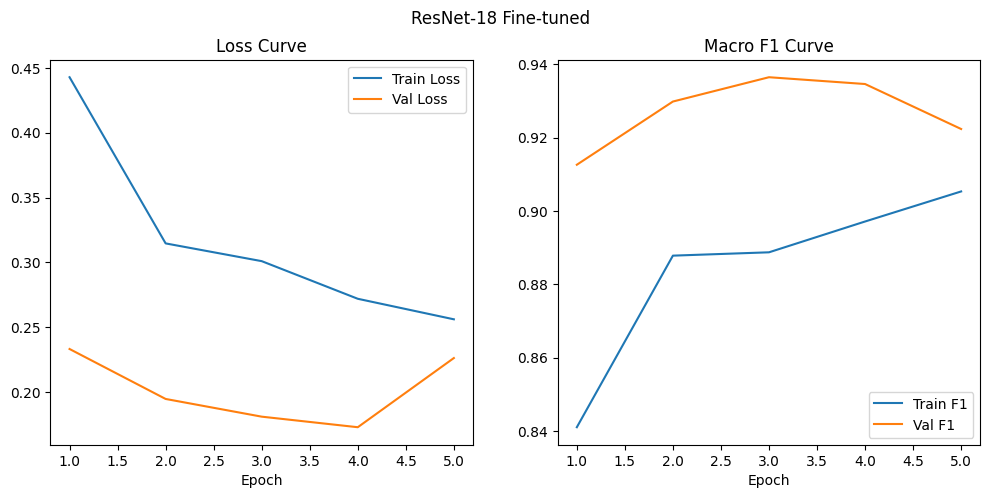

In [20]:
# ============================================================
# 6.1 TRAINING CURVES
# ============================================================

import matplotlib.pyplot as plt

def plot_history(history, title="Training Curves"):
    epochs = [h["epoch"] for h in history]

    train_loss = [h["train"]["loss"] for h in history]
    val_loss = [h["val"]["loss"] for h in history]

    train_f1 = [h["train"]["macro_f1"] for h in history]
    val_f1 = [h["val"]["macro_f1"] for h in history]

    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(epochs, train_loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.legend()

    # F1
    plt.subplot(1,2,2)
    plt.plot(epochs, train_f1, label="Train F1")
    plt.plot(epochs, val_f1, label="Val F1")
    plt.title("Macro F1 Curve")
    plt.xlabel("Epoch")
    plt.legend()

    plt.suptitle(title)
    plt.show()

# Plot for best model
plot_history(tf_ft_history, title="ResNet-18 Fine-tuned")

#### Training Curves Interpretation
The training and validation curves show steady convergence of the model. The training loss consistently decreases across epochs, while the validation loss decreases initially and slightly increases in the final epoch, indicating mild overfitting. The macro F1 score improves for both training and validation, with validation F1 remaining higher than training F1 in early epochs, suggesting good generalization. Overall, the model learns effectively and achieves strong performance without severe overfitting.

#### 6.2 Confusion Matrix

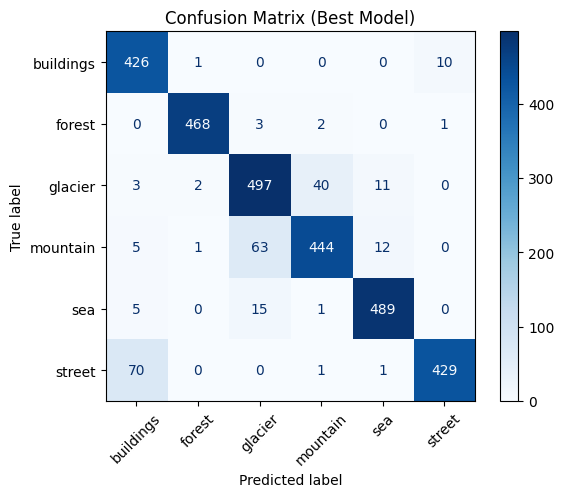

In [21]:
# ============================================================
# 6.2 CONFUSION MATRIX
# ============================================================

import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_predictions(model, loader):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            outputs = model(images)

            pred = torch.argmax(outputs, dim=1).cpu().numpy()
            preds.extend(pred)
            labels.extend(targets.numpy())

    return np.array(labels), np.array(preds)

# Get predictions
y_true, y_pred = get_predictions(tf_ft_trained, test_loader)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix (Best Model)")
plt.show()

#### Confusion Matrix Interpretation
The confusion matrix shows that most classes are correctly classified, as indicated by the strong diagonal values. However, some notable misclassifications are observed. The model frequently confuses glacier and mountain classes, likely due to similar snowy textures and terrain features. Additionally, there is significant confusion between street and buildings, where many street images are predicted as buildings. This is expected because urban scenes often contain overlapping visual elements such as roads and structures. Overall, the model performs well but struggles with visually similar categories.

#### 6.3 Show Misclassified Images

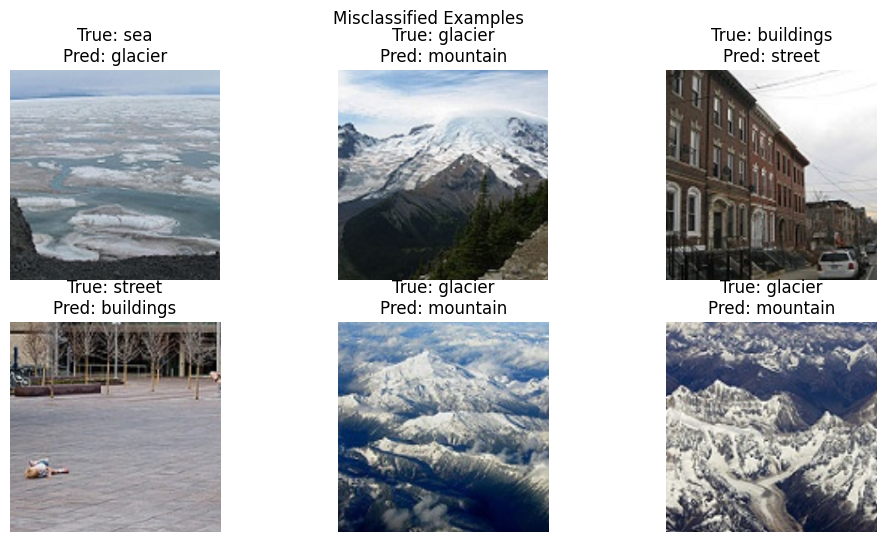

In [22]:
# ============================================================
# 6.3 MISCLASSIFIED SAMPLES
# ============================================================

import random

def show_mistakes(model, loader, num_images=6):
    model.eval()
    mistakes = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            for i in range(len(images)):
                if preds[i] != labels[i]:
                    mistakes.append((
                        images[i].cpu(),
                        labels[i].item(),
                        preds[i].item()
                    ))

    samples = random.sample(mistakes, min(num_images, len(mistakes)))

    plt.figure(figsize=(12,6))
    for i, (img, true, pred) in enumerate(samples):
        plt.subplot(2,3,i+1)
        img = img.permute(1,2,0)

        # unnormalize (approx)
        img = img * torch.tensor([0.229,0.224,0.225]) + torch.tensor([0.485,0.456,0.406])
        img = img.clamp(0,1)

        plt.imshow(img)
        plt.title(f"True: {class_names[true]}\nPred: {class_names[pred]}")
        plt.axis("off")

    plt.suptitle("Misclassified Examples")
    plt.show()

show_mistakes(tf_ft_trained, test_loader)

#### Error Analysis
The misclassified examples reveal that most errors occur due to visual similarity between classes. For instance, sea images with ice or reflective surfaces are sometimes predicted as glacier, while glacier images are often confused with mountains due to similar snowy textures and shapes. Urban scenes also cause confusion, as buildings and streets frequently appear together in the same image. Lighting conditions, background features, and horizon patterns further contribute to these mistakes. These observations indicate that the model relies on global visual patterns, which can lead to ambiguity in closely related scene categories.

# Final Report — Intel Image Classification

## 1. Design Choices

### Activations

We experimented with ReLU, Swish, and HardSwish. ReLU was used as the baseline due to its simplicity and strong performance. Swish and HardSwish were implemented as custom activations to explore smoother gradient behavior and potential performance improvements.

### Layers

We designed a custom ResidualConv block with a learnable scaling parameter and integrated Squeeze-and-Excitation (SE) for channel attention. These were used to improve feature extraction and capture important channel-wise information.

### Loss Functions

We used Cross-Entropy as the baseline loss and experimented with Label Smoothing and Focal Loss. These alternatives were chosen to improve generalization and handle class imbalance.

### Hyperparameters

* Batch size: 64
* Learning rate: 1e-3 (1e-4 for fine-tuning)
* Optimizer: Adam
* Scheduler: ReduceLROnPlateau
* Epochs: 5 (shorter runs for ablation)

These were selected to balance performance and training time.

---

## 2. Model Comparison & Results

| Model                 | Macro F1  | Top-1 Accuracy |
| --------------------- | --------- | -------------- |
| Baseline CNN          | 0.790     | 0.796          |
| Augmented CNN         | 0.753     | 0.749          |
| Transfer (Frozen)     | 0.906     | 0.905          |
| Transfer (Fine-tuned) | **0.919** | **0.918**      |
| CustomNet             | 0.810     | 0.808          |

The fine-tuned ResNet-18 achieved the best performance, demonstrating the effectiveness of transfer learning.

---

## 3. Ablation Study

### Activation

| Activation | Macro F1 |
| ---------- | -------- |
| ReLU       | 0.733    |
| Swish      | 0.673    |
| HardSwish  | 0.716    |

ReLU performed best in this setting, suggesting that simpler activations worked better with limited training.

---

### Loss Function

| Loss            | Macro F1  |
| --------------- | --------- |
| Cross-Entropy   | 0.707     |
| Label Smoothing | 0.720     |
| Focal Loss      | **0.733** |

Focal Loss achieved the best performance, indicating improved handling of difficult examples.

---

### Layer Design

| Model Variant          | Macro F1  |
| ---------------------- | --------- |
| With ResidualConv + SE | **0.737** |
| Without                | 0.618     |

Adding ResidualConv and SE significantly improved performance, showing the benefit of residual learning and channel attention.

---

## 4. Error Analysis

The confusion matrix shows strong overall performance, with most predictions correctly classified. However, some confusion exists between visually similar classes:

* Glacier vs Mountain (similar snowy textures)
* Buildings vs Street (urban overlap)

Misclassified examples indicate that the model sometimes struggles with:

* Similar textures (snow, water reflections)
* Lighting conditions
* Overlapping background features

---

## 5. Final Recommendation

The best model is the fine-tuned ResNet-18, as it achieved the highest macro F1 score and accuracy. It benefits from pretrained ImageNet features and adapts effectively to the dataset.

### Practical Recommendation

* **Desktop / High-resource systems:** Fine-tuned ResNet-18 (best accuracy)
* **Mobile / Resource-constrained devices:** CustomNet (fewer parameters, reasonable performance)

---

## 6. Conclusion

This project demonstrates that transfer learning is highly effective for image classification tasks. While custom architectures and loss functions improve performance, pretrained models still provide the strongest results. Ablation studies confirm that architecture, loss function, and activation choices all influence model performance.
